<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV ,cross_val_score

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
params = {
    'n_estimators' : [50, 100 , 200],
    'max_depth' : [50,100,200]
}

In [ ]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = params ,
    cv = 5,
    scoring = 'accuracy'
)

In [ ]:
grid.fit(X_train , y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [50, 100, 200],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)
print(grid.best_score_)


{'max_depth': 200, 'n_estimators': 200}
0.9648351648351647


In [ ]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [ ]:
best_model = grid.best_estimator_
best_model.fit(X_train , y_train)
y_pred = best_model.predict(X_test)
accuracy_score(y_test , y_pred)
confusion_matrix(y_test , y_pred)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
random = RandomizedSearchCV(
    estimator = RandomForestClassifier(),
    param_distributions = params ,
    cv = 5,
    scoring = 'accuracy'
)

In [ ]:
print(grid.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])


In [ ]:
results = pd.DataFrame(grid.cv_results_)

In [ ]:
results.shape

(9, 15)

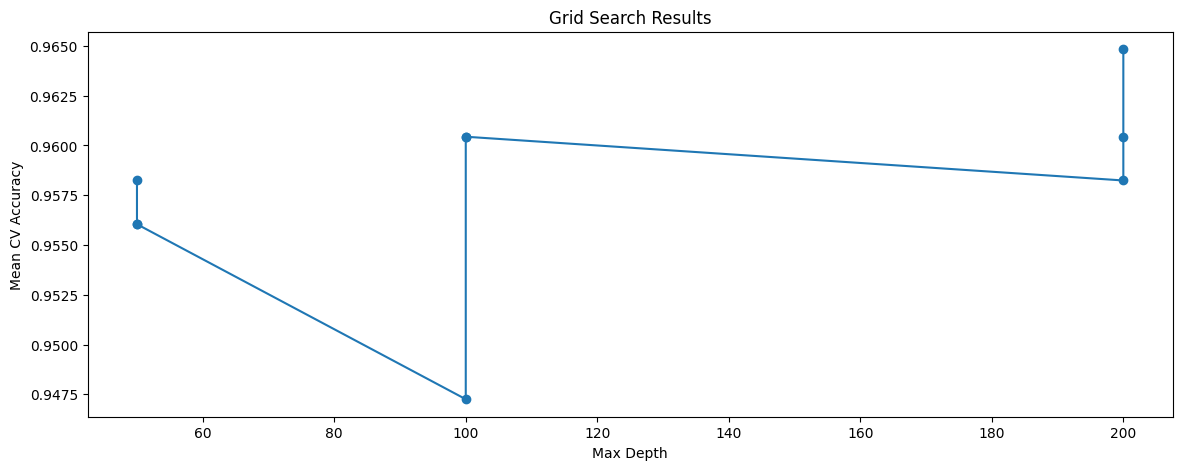

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(  results["param_max_depth"].astype(int),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Grid Search Results")

plt.show()

Q1

Tune a Random Forest model using GridSearchCV with different values of n_estimators and max_depth.

In [ ]:
params = {
    'n_estimators' : [50, 100 , 200],
    'max_depth' : [50,100,200]
}

In [ ]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = params,
    cv = 5,
)

In [ ]:
import time

In [ ]:
st = time.time()
grid.fit(X_train , y_train)
end = time.time()
grid_time = end - st

Q2

Print best_params_, best_score_, and best_estimator_.

In [ ]:
print(grid.best_params_)

{'max_depth': 50, 'n_estimators': 100}


In [ ]:
print(grid.best_score_)

0.9648351648351647


In [ ]:
print(grid.best_estimator_)

RandomForestClassifier(max_depth=50)


Q3

Repeat the experiment using RandomizedSearchCV.

In [ ]:

random = RandomizedSearchCV(
    estimator = RandomForestClassifier(),
    param_distributions = params,
    cv = 5,
)

In [ ]:
st = time.time()
random.fit(X_train, y_train)

end = time.time()
random_time = end - st

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
random.best_params_

{'n_estimators': 200, 'max_depth': 50}

In [ ]:
random.best_estimator_

RandomForestClassifier(max_depth=50, n_estimators=200)

In [ ]:
random.best_score_

np.float64(0.9626373626373625)

Q4

Compare the execution time of GridSearchCV and RandomizedSearchCV.

In [ ]:
print(grid_time , random_time)

25.481009006500244 28.386491775512695


Q5

Convert cv_results_ into a DataFrame and plot the mean cross-validation accuracy.

In [ ]:
results = pd.DataFrame(grid.cv_results_)
results_random = pd.DataFrame(random.cv_results_)

In [ ]:
import seaborn as sns

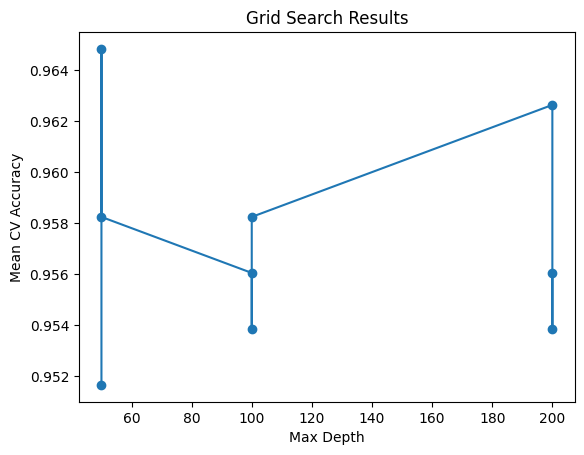

In [ ]:
plt.plot(results['param_max_depth'].astype(int), results['mean_test_score'] , marker = 'o')
plt.xlabel('Max Depth')
plt.ylabel('Mean CV Accuracy')
plt.title('Grid Search Results')
plt.show()

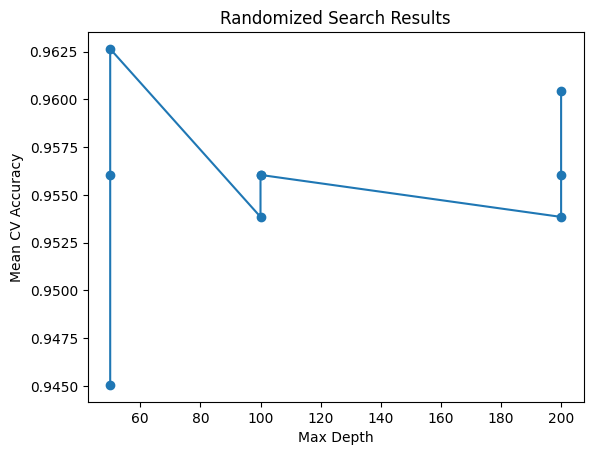

In [ ]:
plt.plot(results_random['param_max_depth'].astype(int), results_random['mean_test_score'] , marker = 'o')
plt.xlabel('Max Depth')
plt.ylabel('Mean CV Accuracy')
plt.title('Randomized Search Results')
plt.show()